In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
device = torch.device('mps')

DATA_ROOT = './data'

FASHION_LABELS = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

In [54]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.FashionMNIST(
    root=DATA_ROOT, train=True,  download=True, transform=transform
)
test_dataset  = torchvision.datasets.FashionMNIST(
    root=DATA_ROOT, train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=0, pin_memory=False)

print(f'train: {len(train_dataset):,}')
print(f'test: {len(test_dataset):,}')

Train samples : 60,000
Test  samples : 10,000


In [ ]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Flatten(),
        )

        flat_dim = 128 * 4 * 4
        self.fc_mu = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.project = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(inplace=True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=3, output_padding=1),
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.project(z).view(-1, 128, 4, 4)
        return self.deconv(x)


class VAE(nn.Module):
    def __init__(self, latent_dim: int):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)

    def reparameterise(self, mu, logvar): # ???
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std

        return mu

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


model = VAE(128).to(device)

In [72]:
def elbo_loss(recon_x, x, mu, logvar):
    """
    ELBO = -BCE(recon, original) + β·KL

    KL  = -½ Σ (1 + log σ² - μ² - σ²)
    """
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return bce + kl, bce.item(), kl.item()

In [ ]:
optimizer = optim.Adam(model.parameters())
history = {'train_loss': [], 'bce': [], 'kl': []}

In [73]:
import tqdm

for epoch in range(30):
    model.train()
    
    tot_loss = tot_bce = tot_kl = 0.0

    for imgs, _ in tqdm.tqdm(train_loader):
        imgs = imgs.to(device)
        
        recon, mu, logvar = model(imgs)
        loss, bce, kl = elbo_loss(recon, imgs, mu, logvar)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        n = imgs.size(0)
        tot_loss += loss.item() * n
        tot_bce += bce * n
        tot_kl += kl * n

    history['train_loss'].append(tot_loss / len(train_dataset))
    history['bce'].append(tot_bce / len(train_dataset))
    history['kl'].append(tot_kl / len(train_dataset))

100%|██████████| 235/235 [00:05<00:00, 40.59it/s]


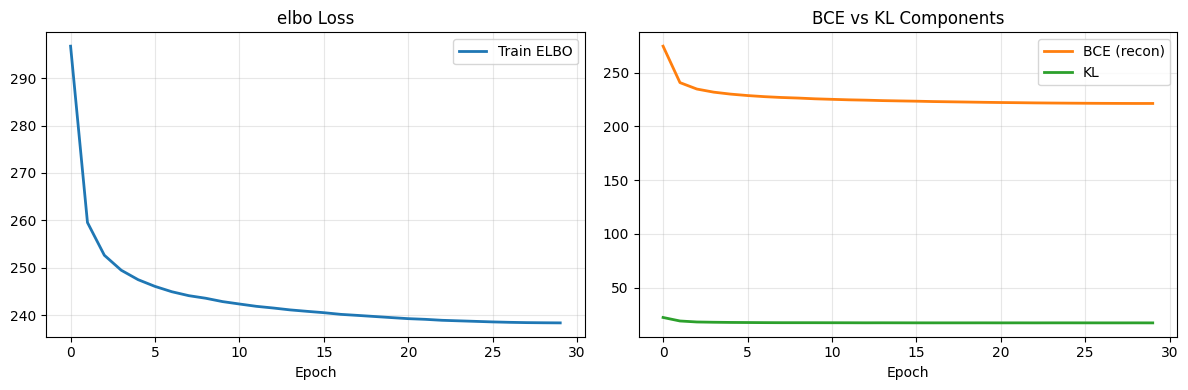

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train ELBO', lw=2)
axes[0].set_title('elbo Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['bce'], label='BCE (recon)', lw=2, color='tab:orange')
axes[1].plot(history['kl'],  label='KL',          lw=2, color='tab:green')
axes[1].set_title('BCE vs KL Components')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

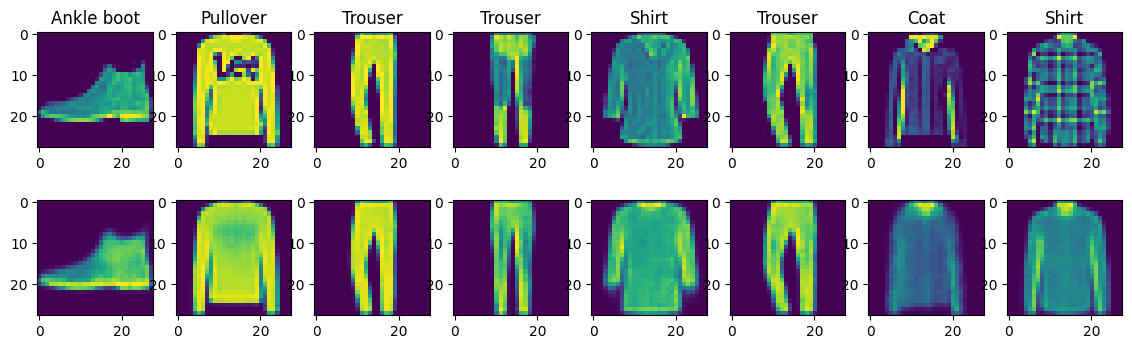

In [65]:
model.eval()
test_imgs, test_labels = next(iter(test_loader))
test_imgs_dev = test_imgs[:8].to(device)

with torch.no_grad():
    recon_imgs, _, _ = model(test_imgs_dev)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(test_imgs[i, 0].numpy())
    axes[0, i].set_title(FASHION_LABELS[test_labels[i]])
    axes[1, i].imshow(recon_imgs[i, 0].cpu().numpy())

plt.show()

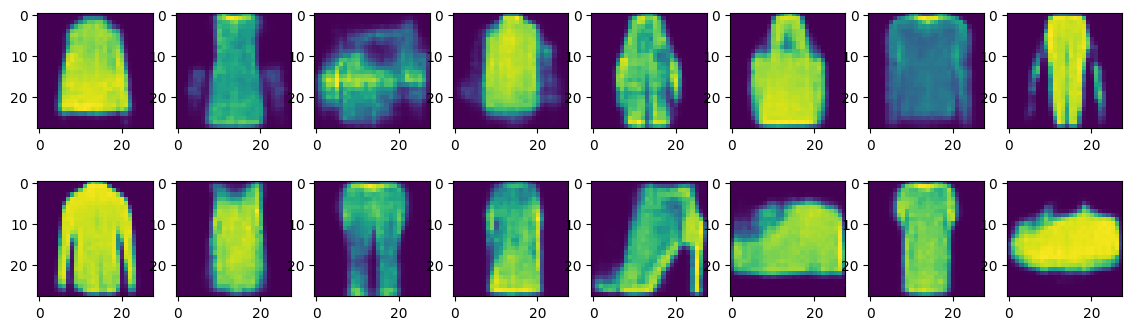

In [63]:
model.eval()

n_samples = 16
samples = model.sample(n_samples, device).cpu()

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(samples[i, 0].numpy())

plt.show()